In [1]:
%matplotlib inline
!pip install deeptrack deeplay 


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


<!--<badge>--><a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack-2.0/blob/develop/tutorials/2-examples/DTEx206_cell_counting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

# Example 6. Cell Counting

Train a U-Net to count the number of cells in the BBBC039 dataset.

## 1. Setup

In [3]:
import os

import deeplay as dl
import deeptrack as dt
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import morphology as skmorph
import torch

## 2. Loading the Dataset

In [5]:
if not os.path.exists("cell_counting_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/cell_counting_dataset")

root = os.path.join("cell_counting_dataset", "cell nuclei")
image_dir = os.path.join(root, "images")
mask_dir = os.path.join(root, "masks")

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

### 2.1 Sample the Dataset

torch.Size([520, 696]) torch.Size([520, 696])


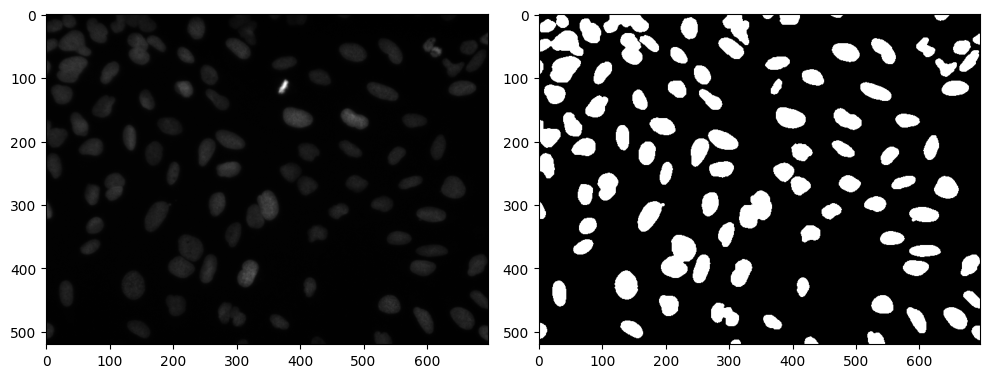

In [4]:
def load_pair(idx):
    """Loads an image with ground truth from file."""
    image = Image.open(os.path.join(image_dir, image_files[idx]))
    image = np.array(image, dtype=np.float32)
    image = image/image.max()
    image = torch.from_numpy(image)

    mask = Image.open(os.path.join(mask_dir, mask_files[idx])).convert("RGB")
    mask = np.array(mask, np.uint8)
    mask = mask.max(axis=2)
    mask = (mask > 0).astype(np.float32)
    mask = torch.from_numpy(mask)

    return image, mask

image, mask = load_pair(0)
print(image.shape, mask.shape)

# Plot a sample.
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image, cmap="gray")
axs[1].imshow(mask, cmap="gray")
plt.tight_layout()
plt.show()

### 2.2 Generating cell-like scatterers.

Cells are represented as ellipsoids with random spatial properties such as area and radii.

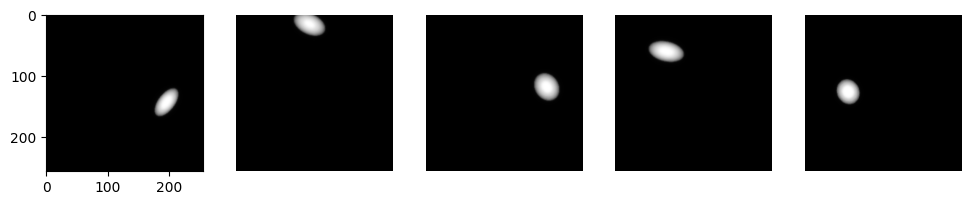

In [5]:
IMAGE_SIZE = 256

# Helper function to keep axis within reasonable parameters.
def random_ellipse_axes():
    """Return the three axes of an ellipse."""
    ellipse_area = (np.random.uniform(3, 4)) ** 2
    radius_ratio = np.random.uniform(1, 1.5)
    major_axis = np.sqrt(ellipse_area) * radius_ratio
    minor_axis = np.sqrt(ellipse_area) / radius_ratio
    z_axis = np.sqrt(ellipse_area) * np.random.uniform(0.2, 0.4)
    return (major_axis, minor_axis, z_axis)* dt.units.um

# Define the ellipse.
ellipse = dt.Ellipsoid(
    radius = random_ellipse_axes,
    intensity=lambda: np.random.uniform(0.5, 1.5),
    position=lambda: np.random.uniform(5, IMAGE_SIZE - 5, size=2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

# Define the microscope.
optics = dt.Fluorescence(
    resolution=1e-6,
    magnification=6,
    wavelength=400e-9,
    NA=lambda: np.random.uniform(0.9, 1.1),
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

# Image the ellipses with a fluorescence microscope.
sim_im_pip = optics(ellipse)

# Plot some samples.
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axs):
    sim_im_pip.update()
    image = sim_im_pip()
    ax.imshow(image, cmap="gray")
    if i != 0: ax.axis("off")
plt.tight_layout()
plt.show()

### 2.3 Improving the Simulation
Adding internal structure to the cells with Poisson noise and elastic transformations will make the cells look more realistic.

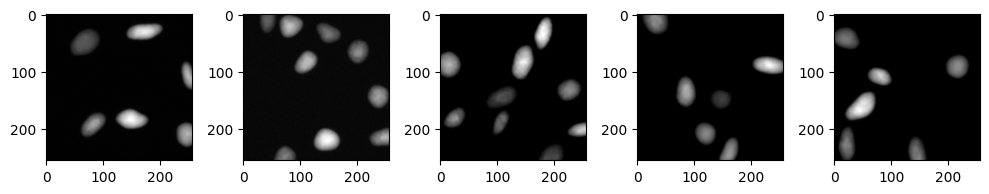

In [6]:
ellipse = dt.Ellipsoid(
    radius = random_ellipse_axes,
    intensity=lambda: np.random.uniform(0.5, 1.5),
    position=lambda: np.random.uniform(5, IMAGE_SIZE - 5, size=2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

# Add elastic transformations.
synthetic_nuclei = (
    (ellipse ^ (lambda: np.random.randint(5, 10)))
    >> dt.Pad(px=(10, 10, 10, 10), keep_size=False)
    >> dt.ElasticTransformation(alpha=100, sigma=10, order=1)
    >> dt.CropTight()
)

# Define Poisson noise and Gaussian blur.
long_range_noise = (synthetic_nuclei >> dt.Poisson(snr=0.2)
                    >> dt.GaussianBlur(sigma=3.5))
short_range_noise = (synthetic_nuclei >> dt.Poisson(snr=1.0)
                     >> dt.GaussianBlur(sigma=1.5))
random_range_noise = (
    synthetic_nuclei
    >> dt.Poisson(snr=lambda: np.random.uniform(0.5, 1.5))
    >> dt.GaussianBlur(sigma=lambda: np.random.uniform(0.75, 1.5))
)

# Combine the augmentations.
noisy_synthetic_nuclei = (
    synthetic_nuclei
    * (long_range_noise + short_range_noise + random_range_noise) / 3
)

# Ensure non-overlapping cells.
non_overlap_nuclei = dt.NonOverlapping(noisy_synthetic_nuclei, min_distance=2)

# Define the microscope.
optics = dt.Fluorescence(
    resolution=1e-6, magnification=6, wavelength=400e-9,
    NA=lambda: np.random.uniform(0.9, 1.1),
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

# Define simulation pipeline with some background noise.
sim_im_pip = (optics(non_overlap_nuclei)
              >> dt.Gaussian(sigma=lambda: np.random.uniform(0, 0.1))
              >> dt.Divide(lambda: np.random.uniform(14, 20))
              >> dt.Add(lambda: np.random.uniform(-0.05, 0.15))
              >> dt.Clip(0, 1) >> dt.AsType("float"))

# Plot some samples.
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axs):
    sim_im_pip.update()
    image = sim_im_pip()
    ax.imshow(image, cmap="gray")

plt.tight_layout()
plt.show()

### 2.4 Generating Ground Truth Masks
We now have a realistic simulation, in order to get a ground truth mask from this we will use the built-in function `SampleToMask`.

In [7]:
def get_mask(radius):
    """Apply isotropic erosion to a binary mask."""
    def inner(mask):
        mask = np.sum(mask, -1, keepdims=True) > 0
        mask = np.pad(mask, [(1, 1), (1, 1), (0, 0)], mode="constant")
        mask = skmorph.isotropic_erosion(mask, radius=radius)
        return mask[1:-1, 1:-1]
    return inner

# Define mask pipeline.
sim_mask_pip = (
    noisy_synthetic_nuclei
    >> dt.SampleToMasks(get_mask, radius=2, output_region=optics.output_region,
                       merge_method="or")
    >> dt.AsType("float")
)

### 2.5 Finalize Training Pipeline

In [8]:
# Combine image simulation and mask pipeline.
sim_im_mask_pip = ((sim_im_pip & sim_mask_pip) >> dt.MoveAxis(2, 0)
                   >> dt.pytorch.ToTensor(dtype=torch.float))

# Generate the training dataset.
train_dataset = dt.pytorch.Dataset(sim_im_mask_pip, length=512, replace=0.01)

Sample the simulated dataset.

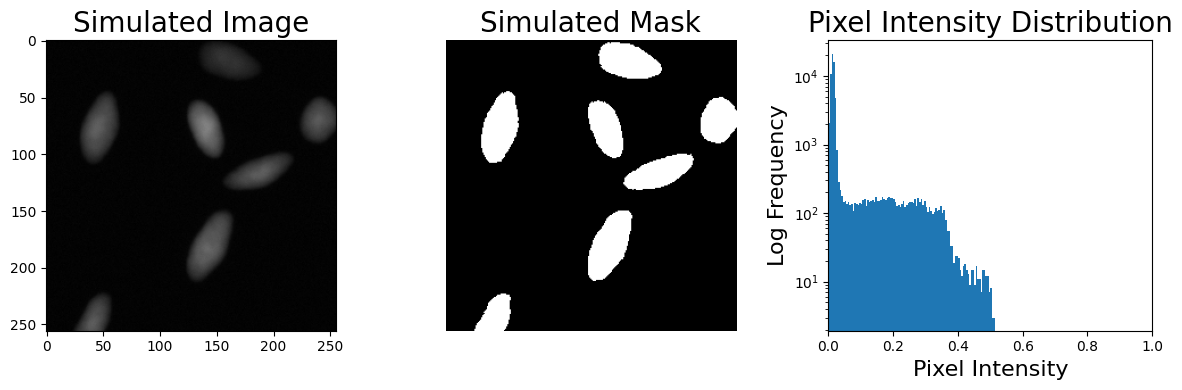

In [9]:
sim_im, sim_mask = train_dataset[np.random.choice(len(train_dataset))]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# Plot image.
axs[0].imshow(sim_im.permute(1, 2, 0), vmin=0, vmax=1, cmap="gray")
axs[0].set_title("Simulated Image", fontsize=20)

# Plot mask.
axs[1].imshow(sim_mask.permute(1, 2, 0), vmin=0, vmax=1, cmap="gray")
axs[1].set_title("Simulated Mask", fontsize=20)
axs[1].axis("off")

# plot intensity distribution.
axs[2].hist(np.array(sim_im).flatten(), bins=200, range=(0, 1))
axs[2].set_xlabel("Pixel Intensity", fontsize=16)
axs[2].set_xlim([0, 1])
axs[2].set_ylabel("Log Frequency", fontsize=16)
axs[2].set_yscale("log")
axs[2].set_title("Pixel Intensity Distribution", fontsize=20)

plt.tight_layout()
plt.show()

## 3. Implementing the U-Net

In [10]:
# Using deeplay U-Net template. 
model = dl.UNet2d(
    in_channels = 1,
    channels=[16, 32, 64,],
    out_channels=1,
)

# Compile as a regressor.
unet_regressor = dl.Regressor(
    model=model, loss=torch.nn.BCEWithLogitsLoss(), optimizer=dl.Adam(),
).create()

print(unet_regressor)

Regressor(
  (loss): BCEWithLogitsLoss()
  (optimizer): Adam[Adam]()
  (train_metrics): MetricCollection,
    prefix=train
  )
  (val_metrics): MetricCollection,
    prefix=val
  )
  (test_metrics): MetricCollection,
    prefix=test
  )
  (model): UNet2d(
    (encoder): ConvolutionalEncoder2d(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
      )
      (postprocess): Identity

### 3.1 Training the U-Net

c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | loss          | BCEWithLogitsLoss | 0      | train
1 | train_metrics | MetricCollection  | 0      | train
2 | v

Training: |          | 0/? [00:00<?, ?it/s]

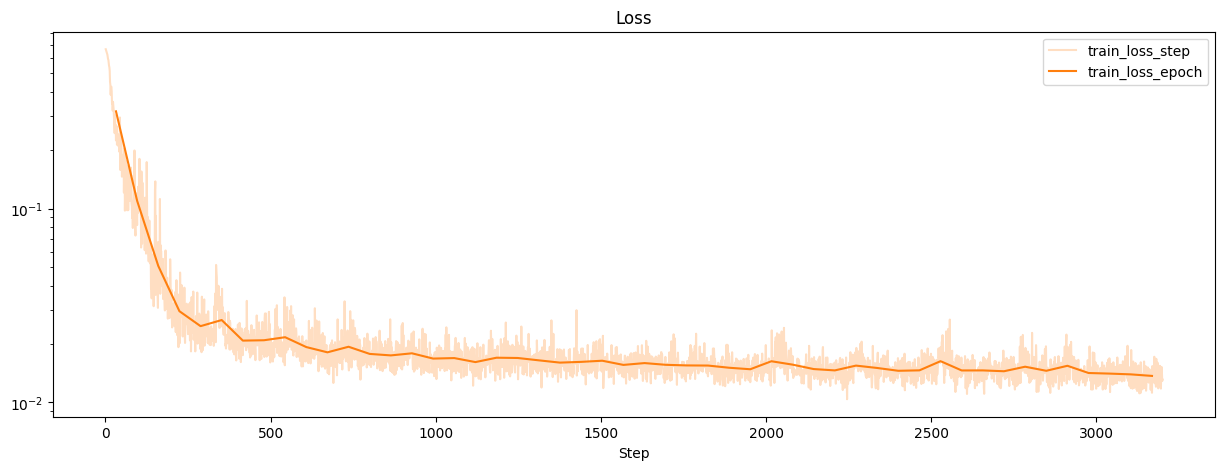

In [11]:
# Define training data loader.
train_loader = dl.DataLoader(train_dataset, batch_size=8, shuffle=True)

# Define model trainer.
unet_trainer = dl.Trainer(max_epochs=50, accelerator="auto")

# Start training.
unet_trainer.fit(unet_regressor, train_loader) 
unet_trainer.history.plot()
unet_regressor.eval();

## 4. Evaluating the Training
Predict the number of cells in each image of the dataset.

In [12]:
images, masks, preds = [], [], []
with torch.no_grad():
    for idx in range(len(image_files)):
        image, mask = load_pair(idx)

        image = image.unsqueeze(0).unsqueeze(0)
        mask  = mask.unsqueeze(0).unsqueeze(0)

        pred = unet_regressor(image)
        pred = torch.sigmoid(pred).cpu()

        images.append(image.cpu())
        masks.append(mask.cpu())
        preds.append(pred)

images = torch.cat(images, dim=0)
masks  = torch.cat(masks, dim=0)
preds  = torch.cat(preds, dim=0)

true_count = np.array([skmorph.label(l.squeeze()).max() for l in masks])
pred_count = np.array([skmorph.label(p.squeeze() > .995).max() for p in preds])

mae = abs(pred_count - true_count).mean()
mpe = (abs(pred_count[true_count > 0] - true_count[true_count > 0])
       / (true_count[true_count > 0])).mean()

Sample a random image and compare. 

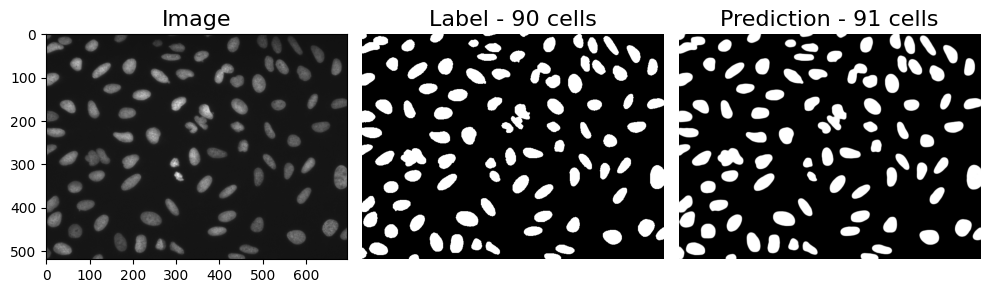

In [13]:
random_sample = np.random.choice(len(images))

fig, axs = plt.subplots(1, 3, figsize=(10, 4))

axs[0].imshow(images[random_sample].squeeze(), vmin=0, vmax=1, cmap="gray")
axs[0].set_title("Image", fontsize=16)

axs[1].imshow(masks[random_sample].squeeze(), vmin=0, vmax=1, cmap="gray")
axs[1].set_title(f"Label - {true_count[random_sample]} cells", fontsize=16)
axs[1].axis("off")

axs[2].imshow(preds[random_sample].squeeze(), cmap="gray")
axs[2].set_title(f"Prediction - {pred_count[random_sample]} cells", fontsize=16)
axs[2].axis("off")

plt.tight_layout()
plt.show()

Plot the predicted cell counts vs. true counts for the whole dataset.

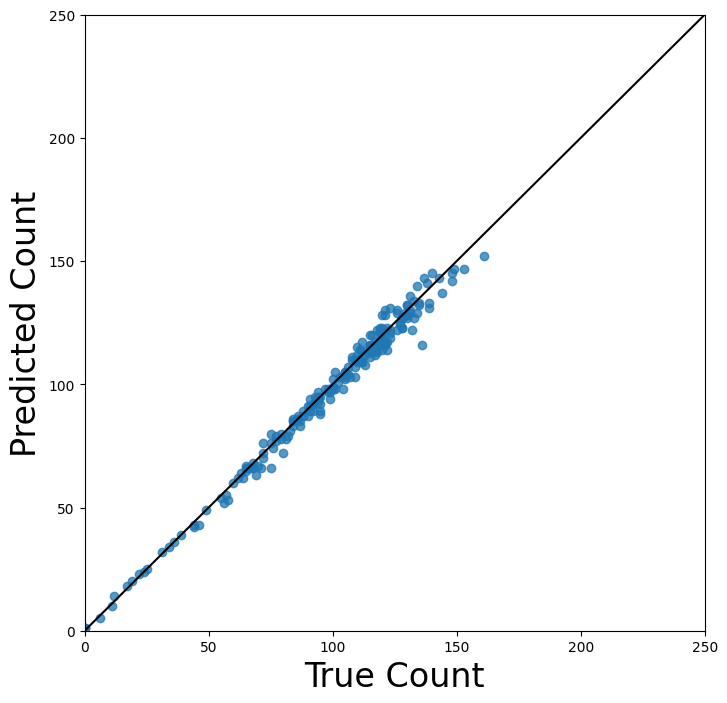

In [14]:
plt.figure(figsize=(8, 8))
plt.scatter(true_count, pred_count, alpha=0.75)
plt.axline([0, 0], [1, 1], color="black")
plt.xlabel("True Count", fontsize=24)
plt.xlim(0, 250)
plt.ylabel("Predicted Count", fontsize=24)
plt.ylim(0, 250)
plt.show()